# masks for mosaic

* Becky has *.pl files for each image

In [14]:
import os
from astropy.io import fits
from astropy.table import Table
from PIL import Image
from matplotlib import pyplot as plt

In [15]:
homedir = os.getenv("HOME")

In [16]:
os.chdir(os.path.join(homedir,"research/HalphaGroups/test_images/mask-dev"))

In [17]:
!ls

chi_gifwcsn4_24030.fits             proto_gifwcsn4_24030.fits
chi_ifwcsn4_24030.fits              proto_ifwcsn4_24030.fits
gifwcsn4_24030.fits                 resi_gifwcsn4_24030.fits
gifwcsn4_24030.weight.fits          resi_ifwcsn4_24030.fits
ifwcsn4_24030_bpm_test_chatgpt.fits samp_gifwcsn4_24030.fits
ifwcsn4_24030_bpm_test.fits         samp_ifwcsn4_24030.fits
ifwcsn4_24030_bpm.pl                snap_gifwcsn4_24030.fits
ifwcsn4_24030.fits                  snap_ifwcsn4_24030.fits
ifwcsn4_24030.weight.fits           test.fits
mosaic_bpm_2013.fits


In [10]:
fname = "ifwcsn4_24030_bpm.fits"

In [12]:
hdu = fits.open(fname, ignore_missing_simple=True)

        Use textwrap.indent() instead. [astropy.io.fits.hdu.hdulist]
    Header size is not multiple of 2880: 597990
There may be extra bytes after the last HDU or the file is corrupted. [astropy.io.fits.hdu.hdulist]


OSError: Empty or corrupt FITS file

In [15]:
tab = Table.read(fname)

IORegistryError: Format could not be identified based on the file name or contents, please provide a 'format' argument.
The available formats are:
           Format           Read Write Auto-identify Deprecated
--------------------------- ---- ----- ------------- ----------
                      ascii  Yes   Yes            No           
               ascii.aastex  Yes   Yes            No           
                ascii.basic  Yes   Yes            No           
                  ascii.cds  Yes    No            No           
     ascii.commented_header  Yes   Yes            No           
                  ascii.csv  Yes   Yes           Yes           
              ascii.daophot  Yes    No            No           
                 ascii.ecsv  Yes   Yes           Yes           
           ascii.fast_basic  Yes   Yes            No           
ascii.fast_commented_header  Yes   Yes            No           
             ascii.fast_csv  Yes   Yes            No           
       ascii.fast_no_

In [17]:
fname = "ifwcsn4_24030_bpm.pl"
#t = Image.open(fname)
t = Image.fromarray(fname)

AttributeError: 'str' object has no attribute '__array_interface__'

In [19]:
!pip install specutils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 965.6/965.6 kB 4.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 2.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.16.1 which is incompatible.


In [21]:
# specutils does not work
import specutils
from specutils import Spectrum1D
fname = "ifwcsn4_24030_bpm.pl"
spec = Spectrum1D.read(fname, format='iraf', ignore_missing_simple=True)

# Help from Facebook Astronomers Group

* Mike Fitzpatrick gave this link: https://docs.astropy.org/en/stable/_modules/astropy/io/fits/hdu/compressed/_codecs.html#PLIO1

In [36]:
filename = "ifwcsn4_24030_bpm.pl"
with open(filename, 'rb') as file:
    binary_data = file.read()

In [39]:
plio1 = fits.hdu.compressed._codecs.PLIO1(tilesize=16)
testarray = plio1.decode(binary_data)

AttributeError: 'bytes' object has no attribute 'dtype'

In [42]:
# from chatgpt

# Assume PLIO1 is already imported
from astropy.io.fits.hdu.compressed._codecs import PLIO1

# Step 1: Read the compressed file into a bytes object
with open(filename, "rb") as f:
    compressed_data = f.read()

# Step 2: Create the PLIO1 codec
codec = PLIO1(tilesize=512)  # tilesize must match how the data was encoded

# Step 3: Decode to get a NumPy array
arr = codec.decode(compressed_data)

print(arr.shape, arr.dtype)
print(arr)

AttributeError: 'bytes' object has no attribute 'dtype'

In [44]:
# take 2 from chatgpt, when I gave it the error

import numpy as np
from astropy.io.fits.hdu.compressed._codecs import PLIO1

# Step 1: Read the compressed PLIO1 file into a NumPy array
with open(filename, "rb") as f:
    compressed_data = np.frombuffer(f.read(), dtype=np.uint8)

# Step 2: Create the codec (tilesize must match original encoding)
codec = PLIO1(tilesize=512)  # 512 is a common default in IRAF, but check!

# Step 3: Decode to get decompressed data
arr = codec.decode(compressed_data)

In [45]:
# Step 4: Reshape if you know the original dimensions
# For example, if the mask was 1024x1024:
# arr = arr.reshape((1024, 1024))

print(arr.shape, arr.dtype)
print(arr[:20])  # peek at first values

(512,) int32
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [51]:
# read in image to get the shape

imdat = fits.getdata('ifwcsn4_24030.fits')

In [52]:
imdat.shape

(8233, 8406)

In [55]:
len(arr)

512

(8233, 8406) int32


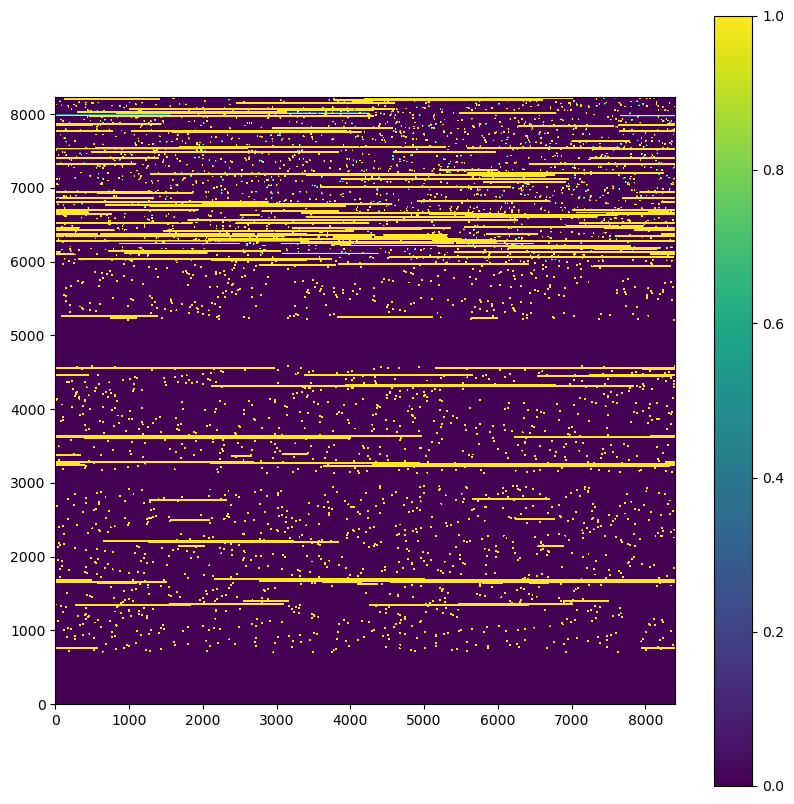

In [6]:
import numpy as np
from astropy.io.fits.hdu.compressed._codecs import PLIO1

# File parameters from header
width = 8406
height = 8233
tilesize = width*height  # for line storage mode

filename = "ifwcsn4_24030_bpm.pl"
with open(filename, "rb") as f:
    compressed_data = np.frombuffer(f.read(), dtype=np.uint8)

codec = PLIO1(tilesize=tilesize)
arr = codec.decode(compressed_data)

arr = arr.reshape((height, width))

print(arr.shape, arr.dtype)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.imshow(arr, origin='lower',vmin=0,vmax=1)
plt.colorbar()
plt.show()
outfile = filename.replace('.pl','_test.fits')
fits.writeto(outfile, outarr, overwrite=True) 

In [1]:
import numpy as np
from astropy.io.fits.hdu.compressed._codecs import PLIO1
from astropy.io import fits

# In "line storage mode", tilesize = image width
# File parameters from header
height = 8233
width = 8406

tilesize = width*height  # for line storage mode
tilesize = width

shape = (width, height)

outarr =  np.zeros((height, width), dtype=np.int32)
print(outarr.shape)
filename = "ifwcsn4_24030_bpm.pl"
rowindex=0
badcount = 0
with open(filename, "rb") as f:
    codec = PLIO1(tilesize=tilesize)
    for line in f.readlines():
        compressed_data = np.frombuffer(line, dtype=np.uint8)
        arr = codec.decode(compressed_data)
        print(arr.shape,outarr.shape)
        outarr[rowindex,:] = arr
        rowindex += 1
        
        if rowindex >= (nrow):
            print(f'problem with formatting...{badcount}')
            badcount += 1
            break
#arr = arr.reshape((height, width))

#print(arr.shape, arr.dtype)

import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.imshow(outarr, origin='lower',vmin=0,vmax=1)
plt.colorbar()
plt.show()


outfile = filename.replace('.pl','_test.fits')
fits.writeto(outfile, outarr, overwrite=True) 




(8233, 8406)


FileNotFoundError: [Errno 2] No such file or directory: 'ifwcsn4_24030_bpm.pl'

(1, 8406) int32


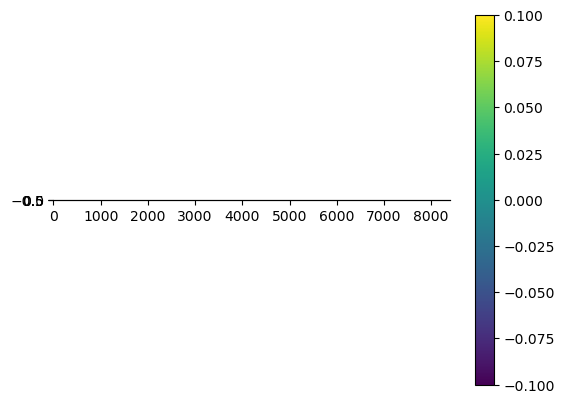

In [6]:
import numpy as np
from astropy.io.fits.hdu.compressed._codecs import PLIO1

# File parameters from header
width = 8406
height = 8233
tilesize = width  # for line storage mode

with open("ifwcsn4_24030_bpm.pl", "rb") as f:
    compressed_data = np.frombuffer(f.read(), dtype=np.uint8)

codec = PLIO1(tilesize=tilesize)
arr = codec.decode(compressed_data)

arr = arr.reshape((1, width))

print(arr.shape, arr.dtype)

import matplotlib.pyplot as plt
plt.imshow(arr, origin='lower')
plt.colorbar()
plt.show()

In [9]:
os.listdir()

['samp_ifwcsn4_24030.fits',
 'ifwcsn4_24030_bpm.pl',
 'mosaic_bpm_2013.fits',
 'snap_ifwcsn4_24030.fits',
 'proto_gifwcsn4_24030.fits',
 'gifwcsn4_24030.fits',
 'test.fits',
 'gifwcsn4_24030.weight.fits',
 'resi_gifwcsn4_24030.fits',
 'resi_ifwcsn4_24030.fits',
 'chi_gifwcsn4_24030.fits',
 'ifwcsn4_24030.weight.fits',
 'ifwcsn4_24030_bpm_test.fits',
 'proto_ifwcsn4_24030.fits',
 'chi_ifwcsn4_24030.fits',
 'snap_gifwcsn4_24030.fits',
 'samp_gifwcsn4_24030.fits',
 'ifwcsn4_24030.fits']

In [15]:
import numpy as np
from astropy.io.fits.hdu.compressed._codecs import PLIO1

width = 8406
height = 8233
tilesize = width
header_bytes = 16000 * 2  # skip IRAF user area

arr = np.empty((height, width), dtype=np.int32)
filename = 'ifwcsn4_24030_bpm.pl'
with open(filename, "rb") as f:
    f.seek(header_bytes)

    codec = PLIO1(tilesize=tilesize)

    for row in range(height):
        # Read 2-byte length of compressed tile
        #clen = int(np.frombuffer(f.read(), dtype='>u2'))  # big-endian unsigned short
        # Read that many bytes of compressed data
        #cdata = np.frombuffer(f.read(clen), dtype=np.uint8)
        cdata = np.frombuffer(f.read(), dtype=np.uint8)
        # Decode
        arr[row, :] = codec.decode(cdata)

print(arr.shape, arr.dtype)

outfile = filename.replace('.pl','_test.fits')
fits.writeto(outfile, arr, overwrite=True) 

(8233, 8406) int32


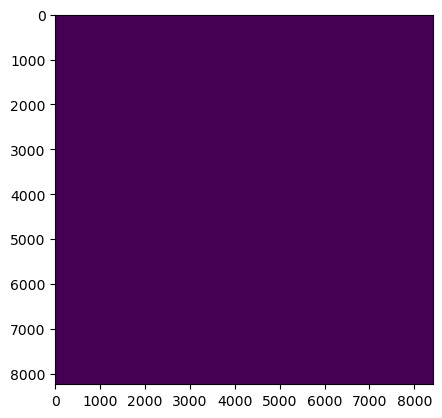

In [16]:
plt.imshow(arr, vmin=0, vmax=1)

(8233, 8406) int32


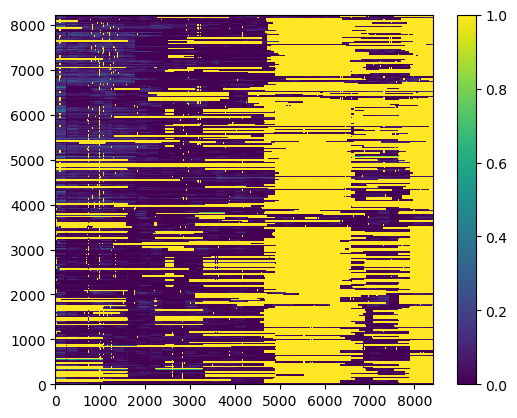

In [35]:
import numpy as np
from astropy.io.fits.hdu.compressed._codecs import PLIO1

width = 8406
height = 8233
tilesize = width
header_bytes = 16000 * 2  # skip IRAF user area
header_bytes = 16000   # skip IRAF user area
arr = np.empty((height, width), dtype=np.int32)

with open("ifwcsn4_24030_bpm.pl", "rb") as f:
    f.seek(header_bytes)

    codec = PLIO1(tilesize=tilesize)

    for row in range(height):
        # Read 2-byte length of compressed tile
        #clen = int(np.frombuffer(f.read(2), dtype='>u2')[0])  # big-endian unsigned short
        clen = int(np.frombuffer(f.read(2), dtype=np.uint8)[0])
        # Read that many bytes of compressed data
        cdata = np.frombuffer(f.read(clen), dtype=np.uint8)
        # Decode
        arr[row, :] = codec.decode(cdata)

print(arr.shape, arr.dtype)
f.close()
plt.figure()
plt.imshow(arr, origin='lower', vmin=0, vmax=1)
plt.colorbar()
plt.show()

(8233, 8406) int32


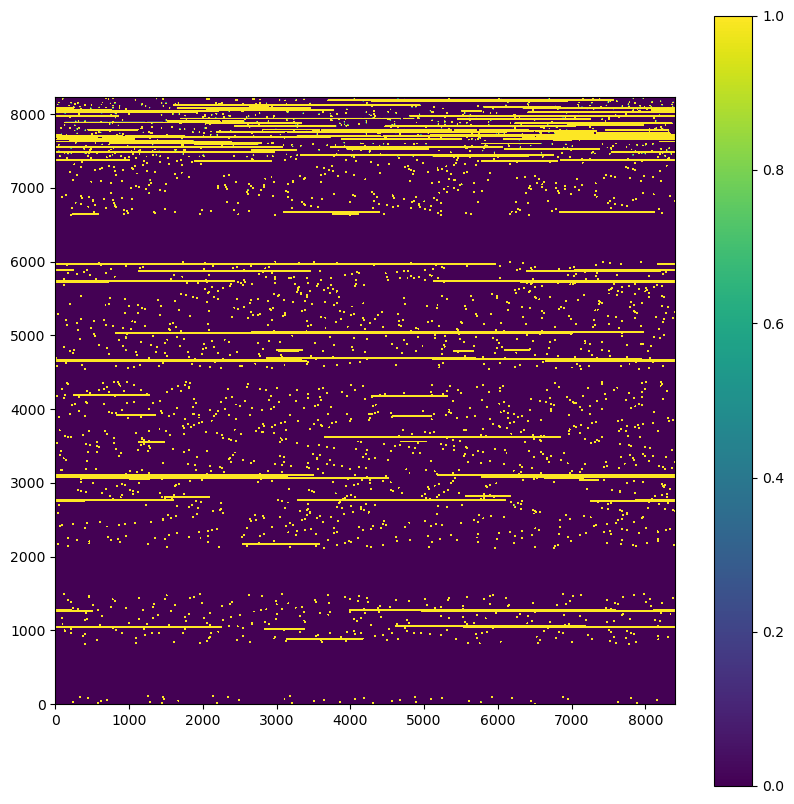

In [45]:
import numpy as np
from astropy.io.fits.hdu.compressed._codecs import PLIO1
import matplotlib.pyplot as plt

width = 8406
height = 8233
tilesize = width*height  # one row per tile
header_bytes = 16000 * 1  # skip IRAF user area

with open("ifwcsn4_24030_bpm.pl", "rb") as f:
    f.seek(header_bytes)
    compressed_data = np.frombuffer(f.read(), dtype=np.uint8)

codec = PLIO1(tilesize=tilesize)
arr = codec.decode(compressed_data)

arr = arr.reshape((height, width))

print(arr.shape, arr.dtype)

plt.figure(figsize=(10,10))
plt.imshow(arr, origin='lower', vmin=0, vmax=1)
plt.colorbar()
plt.show()

outfile = filename.replace('.pl','_test_chatgpt.fits')
fits.writeto(outfile, arr, overwrite=True) 

In [18]:
!ls

chi_gifwcsn4_24030.fits             proto_gifwcsn4_24030.fits
chi_ifwcsn4_24030.fits              proto_ifwcsn4_24030.fits
gifwcsn4_24030.fits                 resi_gifwcsn4_24030.fits
gifwcsn4_24030.weight.fits          resi_ifwcsn4_24030.fits
ifwcsn4_24030_bpm_test_chatgpt.fits samp_gifwcsn4_24030.fits
ifwcsn4_24030_bpm_test.fits         samp_ifwcsn4_24030.fits
ifwcsn4_24030_bpm.pl                snap_gifwcsn4_24030.fits
ifwcsn4_24030.fits                  snap_ifwcsn4_24030.fits
ifwcsn4_24030.weight.fits           test.fits
mosaic_bpm_2013.fits


In [40]:
header_bytes = 16000 * 1

with open("ifwcsn4_24030_bpm.pl", "rb") as f:
    raw = f.read()

print(f"File size: {len(raw)} bytes")
print(f"First 64 bytes after header: {raw[header_bytes:header_bytes+64]}")


File size: 597990 bytes
First 64 bytes after header: b'Q\xf5P\x0cQ\xf8\x00\x01HH\x00\x01\x00\x07\xff\x9c\x00"\x00\x00\x00"\x00\x00C\xfeQ\xf5P\x02\x00\x05@\x02\x01\xf4@ZQ\xf7\x00\x07@\x02\x01\xf5@\nQ\xf7\x00\x06@\x02\x01\xf6@XQ\xf7P\x08Q\xf8'


❌ Arrays differ in 3054030 pixels.


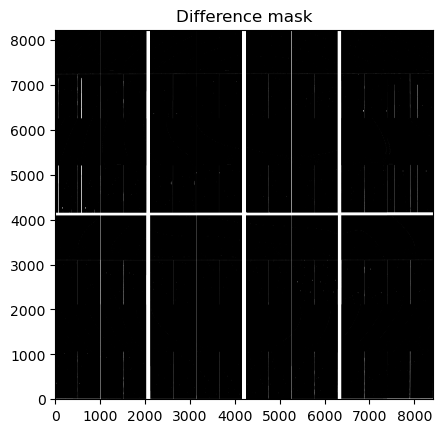

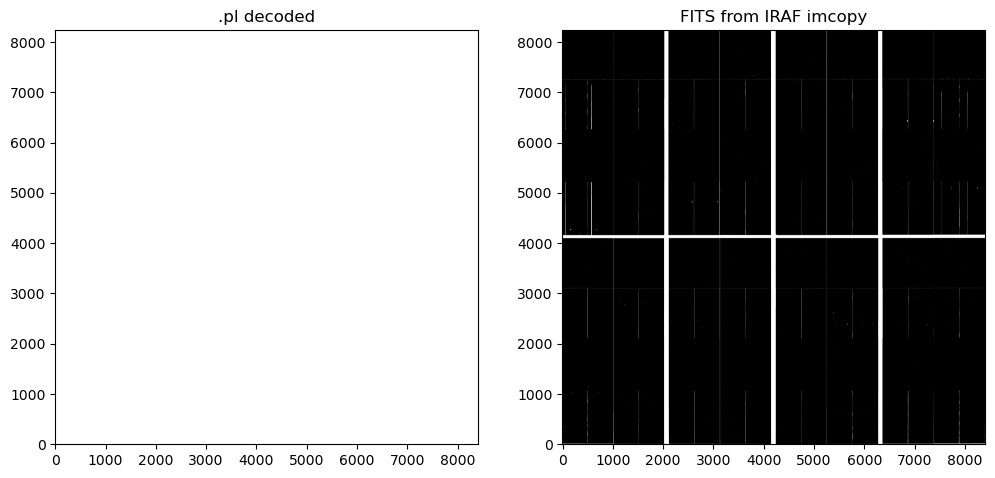

In [37]:
import numpy as np
from astropy.io.fits.hdu.compressed._codecs import PLIO1
from astropy.io import fits
import matplotlib.pyplot as plt

# Parameters from header
width = 8406
height = 8233
header_bytes = 16000 * 2  # skip user area
tilesize = width * height  # one tile for the entire image

plfile = "ifwcsn4_24030_bpm.pl"

fitsfile = "test.fits"

# --- Read .pl file ---
with open(plfile, "rb") as f:
    f.seek(header_bytes)
    compressed_data = np.frombuffer(f.read(), dtype=np.uint8)

codec = PLIO1(tilesize=tilesize)
pl_array = codec.decode(compressed_data).reshape((height, width))

# --- Read FITS version from IRAF imcopy ---
fits_array = fits.getdata(fitsfile)

# --- Compare arrays ---
if np.array_equal(pl_array, fits_array):
    print("✅ The arrays match exactly.")
else:
    diff_pixels = np.count_nonzero(pl_array != fits_array)
    print(f"❌ Arrays differ in {diff_pixels} pixels.")
    # Optional: show where differences occur
    diff_mask = pl_array != fits_array
    plt.figure()
    plt.imshow(diff_mask, origin='lower', cmap='gray')
    plt.title("Difference mask")
    plt.show()

# --- Visual check ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(pl_array, origin='lower', cmap='gray')
axes[0].set_title(".pl decoded")
axes[1].imshow(fits_array, origin='lower', cmap='gray')
axes[1].set_title("FITS from IRAF imcopy")
plt.show()


In [21]:
import numpy as np
from astropy.io.fits.hdu.compressed._codecs import PLIO1
import matplotlib.pyplot as plt
from astropy.io import fits

width = 8406
height = 8233
tilesize = width            # one tile per row
header_bytes = 16000 * 2    # skip user area

arr = np.empty((height, width), dtype=np.int32)

plfile = "ifwcsn4_24030_bpm.pl"
fitsfile = "test.fits"

with open(plfile, "rb") as f:
    f.seek(header_bytes)
    codec = PLIO1(tilesize=tilesize)

    for row in range(height):
        # read length of this tile (2 bytes, big endian unsigned short)
        length_bytes = f.read(2)
        if not length_bytes:
            raise EOFError(f"Unexpected end of file at row {row}")
        clen = int(np.frombuffer(length_bytes, dtype=">u2")[0])

        # read compressed tile
        cdata = np.frombuffer(f.read(clen), dtype=np.uint8)
        arr[row, :] = codec.decode(cdata)

print("Decoded array shape:", arr.shape)

# Compare with FITS version from IRAF imcopy
fits_array = fits.getdata(fitsfile)

if np.array_equal(arr, fits_array):
    print("✅ Arrays match exactly.")
else:
    diff_pixels = np.count_nonzero(arr != fits_array)
    print(f"❌ Arrays differ in {diff_pixels} pixels.")

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(arr, origin="lower", cmap="gray")
axes[0].set_title(".pl decoded")
axes[1].imshow(fits_array, origin="lower", cmap="gray")
axes[1].set_title("FITS from imcopy")
plt.show()


EOFError: Unexpected end of file at row 38

❌ Arrays differ in 3053976 pixels.


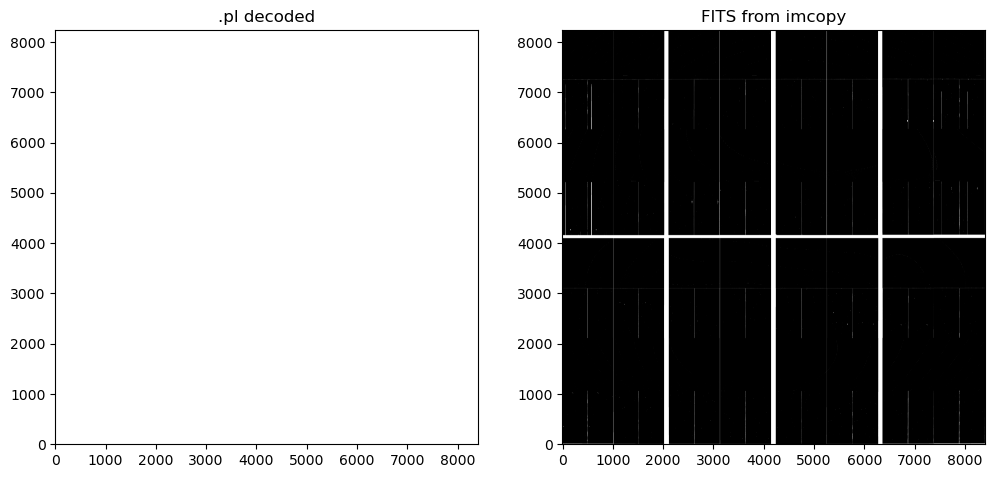

In [23]:
import numpy as np
from astropy.io.fits.hdu.compressed._codecs import PLIO1
from astropy.io import fits
import matplotlib.pyplot as plt

def read_iraf_pl(filename, width, height, user_area_su=16000):
    """
    Read an IRAF .pl PLIO1 mask file and return a numpy array.

    Parameters
    ----------
    filename : str
        Path to the .pl file
    width : int
        Width of the image
    height : int
        Height of the image
    user_area_su : int, optional
        Length of the IRAF user area in short units (2 bytes each)

    Returns
    -------
    np.ndarray
        Decoded image of shape (height, width)
    """
    header_bytes = user_area_su * 2  # convert to bytes
    arr = np.empty((height, width), dtype=np.int32)

    with open(filename, "rb") as f:
        f.seek(header_bytes)
        # read the first 2 bytes to detect tile length
        first_len_bytes = f.read(2)
        if not first_len_bytes:
            raise ValueError("File too short or missing data")
        first_tile_len = int(np.frombuffer(first_len_bytes, dtype=">u2")[0])
        first_tile_data = np.frombuffer(f.read(first_tile_len), dtype=np.uint8)

        # decode first tile to see how many pixels it contains
        codec = PLIO1(tilesize=width*height)  # temporary large value
        decoded_first = codec.decode(first_tile_data)
        pixels_per_tile = len(decoded_first)

        # reset to start of first tile
        f.seek(header_bytes)

        # now decode all tiles
        codec = PLIO1(tilesize=pixels_per_tile)
        row = 0
        while row < height:
            len_bytes = f.read(2)
            if not len_bytes:
                break
            clen = int(np.frombuffer(len_bytes, dtype=">u2")[0])
            cdata = np.frombuffer(f.read(clen), dtype=np.uint8)
            decoded = codec.decode(cdata)

            # place decoded pixels into array
            n_pixels = len(decoded)
            arr[row:row + n_pixels // width, :] = decoded.reshape(-1, width)
            row += n_pixels // width

    if row != height:
        print(f"⚠️ Warning: decoded {row} rows but expected {height}")

    return arr


# Example usage
width = 8406
height = 8233
pl_file = "ifwcsn4_24030_bpm.pl"
fits_file = "test.fits"

pl_array = read_iraf_pl(pl_file, width, height)
fits_array = fits.getdata(fits_file)

# Compare
if np.array_equal(pl_array, fits_array):
    print("✅ Arrays match exactly.")
else:
    diff_pixels = np.count_nonzero(pl_array != fits_array)
    print(f"❌ Arrays differ in {diff_pixels} pixels.")

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(pl_array, origin="lower", cmap="gray")
axes[0].set_title(".pl decoded")
axes[1].imshow(fits_array, origin="lower", cmap="gray")
axes[1].set_title("FITS from imcopy")
plt.show()


In [25]:
pl_file = "ifwcsn4_24030_bpm.pl"
fits_file = "test.fits"

#pl_array = read_iraf_pl(pl_file, width, height)
pl_hdu = fits.open(pl_file, compression='PLIO_1', ignore_missing_simple=True)
#fits_array = fits.getdata(fits_file)

        Use textwrap.indent() instead. [astropy.io.fits.hdu.hdulist]
    Header size is not multiple of 2880: 597990
There may be extra bytes after the last HDU or the file is corrupted. [astropy.io.fits.hdu.hdulist]


OSError: Empty or corrupt FITS file

# Down the rabbit hole of iraf github

* `t_imcopy.x` https://github.com/iraf-community/iraf/blob/e20dd5362ae7111458f7420ac1921a2a9f31efff/pkg/images/imutil/src/t_imcopy.x
* `call img_imcopy (image1, image2, verbose)`
* `img_imcopy` is in `imcopy.x` https://github.com/iraf-community/iraf/blob/e20dd5362ae7111458f7420ac1921a2a9f31efff/pkg/images/lib/imcopy.x#L5

* reads in the input image using:
```
# Map the input image.
im1 = immap (image1, READ_ONLY, 0)
```

* `immap.x` calls `pointer	immapz()`
* also calls `call iki_init()`
* immapz calls
```
# Parse the full image specification into its component parts.
call imparse (inname, Memc[cluster],SZ_PATHNAME,
Memc[ksection],SZ_FNAME, Memc[section],SZ_FNAME, cl_index,cl_size)
```

also this:

```
	# Physically open the image and read the header.  Note that IKI_OPEN
	# may realloc the image descriptor if additional space is required,
	# hence the pointer IM may be modified.

	iferr {
	    call iki_open (im, Memc[cluster], Memc[ksection],
		cl_index, cl_size, acmode, hdr_arg)
	} then {
	    call mfree (im, TY_STRUCT)
	    call erract (EA_ERROR)
	}
```

* looking into `iki_open` https://github.com/iraf-community/iraf/blob/e20dd5362ae7111458f7420ac1921a2a9f31efff/sys/imio/iki/ikiopen.x#L8

```
        # Select an image kernel by calling the access function in each
		# loaded kernel until somebody claims the image.  In the case
		# of a new image, the access function tests only the legality
		# of the extn.  If no extn is given but the imagefile has an
		# extension, the access procedure will fill in the extn field.

		k = 0
		for (i=1;  i <= k_nkernels;  i=i+1) {
		    call strcpy (Memc[extn], Memc[textn], MAX_LENEXTN)
		    call zcall5 (IKI_ACCESS(i), i, Memc[root], Memc[textn],
			clmode, status)

		    if (status == YES) {
			if (k == 0) {
			    # Stop on the first match if an explicit extension
			    # was given.

			    k = i
			    call strcpy (Memc[textn], Memc[fextn], MAX_LENEXTN)
			    if (Memc[extn] != EOS)
				break

			} else if (Memc[extn] == EOS) {
			    # If no extension was given and we match multiple
			    # files then we have an ambiguous name and k=ERR.

			    k = ERR
			    break
			}
		    }
		}
```

* so now looking for `IKI_ACCESS` https://github.com/iraf-community/iraf/blob/e20dd5362ae7111458f7420ac1921a2a9f31efff/sys/imio/iki/ikiaccess.x#L6
* `iki_parse`
* which calls `iki_validextn` which is in `ikiextn.x` https://github.com/iraf-community/iraf/blob/e20dd5362ae7111458f7420ac1921a2a9f31efff/sys/imio/iki/ikiextn.x#L7
* calls some stuff in `iki.com`